# Financial Fraud Detection System



## Module 1: Data Loading, EDA & Preprocessing Pipeline

**Dataset:** IEEE-CIS Fraud Detection (Kaggle)  
**Goal:** Build a production-ready preprocessing pipeline before modeling

## 1.1 Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import gc

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

SEED = 42
np.random.seed(SEED)

---
## 1.2 Load Data

In [2]:
DATA_DIR = '/kaggle/input/competitions/ieee-fraud-detection'
train_transaction = pd.read_csv(os.path.join(DATA_DIR, 'train_transaction.csv'))

train_identity = pd.read_csv(os.path.join(DATA_DIR, 'train_identity.csv'))

print(f'Transaction table: {train_transaction.shape}')
print(f'Identity table:    {train_identity.shape}')


Transaction table: (590540, 394)
Identity table:    (144233, 41)


In [3]:
train_transaction

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5000,W,13926,NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,2.0000,0.0000,1.0000,1.0000,14.0000,NaN,13.0000,NaN,NaN,NaN,NaN,NaN,NaN,13.0000,13.0000,NaN,NaN,NaN,0.0000,T,T,T,M2,...,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0000,W,2755,404.0000,150.0000,mastercard,102.0000,credit,325.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,M0,...,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0000,W,4663,490.0000,150.0000,visa,166.0000,debit,330.0000,87.0000,287.0000,NaN,outlook.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000,315.0000,NaN,NaN,NaN,315.0000,T,T,T,M0,...,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0000,W,18132,567.0000,150.0000,mastercard,117.0000,debit,476.0000,87.0000,NaN,NaN,yahoo.com,NaN,2.0000,5.0000,0.0000,0.0000,0.0000,4.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,25.0000,1.0000,112.0000,112.0000,0.0000,94.0000,0.0000,NaN,NaN,NaN,NaN,84.0000,NaN,NaN,NaN,NaN,111.0000,NaN,NaN,NaN,M0,...,1.0000,1.0000,1.0000,1.0000,38.0000,24.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,50.0000,1758.0000,925.0000,0.0000,354.0000,0.0000,135.0000,0.0000,0.0000,0.0000,50.0000,1404.0000,790.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0000,H,4497,514.0000,150.0000,mastercard,102.0000,credit,420.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [4]:
train_identity

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0000,70787.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0000,NotFound,NaN,-480.0000,New,NotFound,166.0000,NaN,542.0000,144.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0000,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0000,98945.0000,NaN,NaN,0.0000,-5.0000,NaN,NaN,NaN,NaN,100.0000,NotFound,49.0000,-300.0000,New,NotFound,166.0000,NaN,621.0000,500.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0000,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0000,191631.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000,100.0000,NotFound,52.0000,NaN,Found,Found,121.0000,NaN,410.0000,142.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0000,221832.0000,NaN,NaN,0.0000,-6.0000,NaN,NaN,NaN,NaN,100.0000,NotFound,52.0000,NaN,New,NotFound,225.0000,NaN,176.0000,507.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0000,7460.0000,0.0000,0.0000,1.0000,0.0000,NaN,NaN,0.0000,0.0000,100.0000,NotFound,NaN,-300.0000,Found,Found,166.0000,15.0000,529.0000,575.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0000,1280x800,match_status:2,T,F,T,T,desktop,MacOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144228,3577521,-15.0000,145955.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000,100.0000,NotFound,27.0000,NaN,Found,Found,225.0000,NaN,427.0000,139.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 66.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,F3111 Build/33.3.A.1.97
144229,3577526,-5.0000,172059.0000,NaN,NaN,1.0000,-5.0000,NaN,NaN,NaN,NaN,100.0000,NotFound,27.0000,-300.0000,New,NotFound,166.0000,15.0000,352.0000,333.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.1.1,chrome 55.0 for android,32.0000,855x480,match_status:2,T,F,T,F,mobile,A574BL Build/NMF26F
144230,3577529,-20.0000,632381.0000,NaN,NaN,-1.0000,-36.0000,NaN,NaN,NaN,NaN,100.0000,NotFound,27.0000,NaN,New,NotFound,225.0000,27.0000,567.0000,411.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 65.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,Moto E (4) Plus Build/NMA26.42-152
144231,3577531,-5.0000,55528.0000,0.0000,0.0000,0.0000,-7.0000,NaN,NaN,0.0000,0.0000,100.0000,NotFound,27.0000,-300.0000,Found,Found,166.0000,15.0000,352.0000,368.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_9_5,chrome 66.0,24.0000,2560x1600,match_status:2,T,F,T,F,desktop,MacOS


---
## 1.3 Business Framing

Before any modeling, understand what I am solving for.

In [5]:
fraud_rate = train_transaction['isFraud'].mean()
total_transactions = len(train_transaction)
fraud_transactions = train_transaction['isFraud'].sum()
avg_transaction_amt = train_transaction['TransactionAmt'].mean()
fraud_amt = train_transaction.loc[train_transaction['isFraud'] == 1, 'TransactionAmt'].sum()


print('BUSINESS CONTEXT SUMMARY')
print()
print(f'Total transactions:        {total_transactions:>10,}')
print(f'Fraudulent transactions:   {int(fraud_transactions):>10,}')
print(f'Fraud rate:                {fraud_rate:>10.2%}')
print(f'Avg transaction amount:    ${avg_transaction_amt:>9.2f}')
print(f'Total fraud amount ($):    ${fraud_amt:>9,.2f}')
print('=' * 55)
print()
print('Class imbalance note:')
print(f'=For every 1 fraud, there are ~{int((1-fraud_rate)/fraud_rate)} legitimate transactions.')
print('Standard accuracy is misleading — I optimize for AUC-PR.')

BUSINESS CONTEXT SUMMARY

Total transactions:           590,540
Fraudulent transactions:       20,663
Fraud rate:                     3.50%
Avg transaction amount:    $   135.03
Total fraud amount ($):    $3,083,844.86

Class imbalance note:
=For every 1 fraud, there are ~27 legitimate transactions.
Standard accuracy is misleading — I optimize for AUC-PR.


---
## 1.4 Exploratory Data Analysis

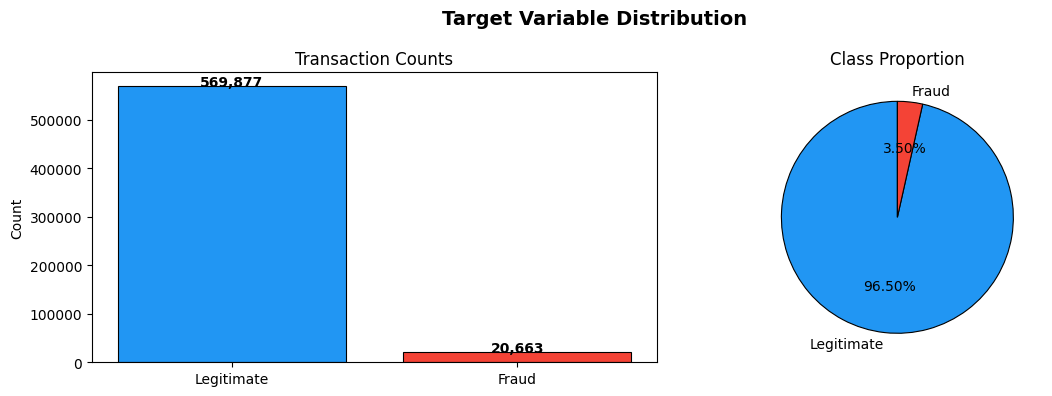

Saved: class_distribution.png


In [6]:
# 1.4.1 Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')

counts = train_transaction['isFraud'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], counts.values,
            color=['#2196F3', '#F44336'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Transaction Counts')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Legitimate', 'Fraud'],
            colors=['#2196F3', '#F44336'], autopct='%1.2f%%',
            startangle=90, wedgeprops=dict(edgecolor='black', linewidth=0.8))
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_distribution.png')

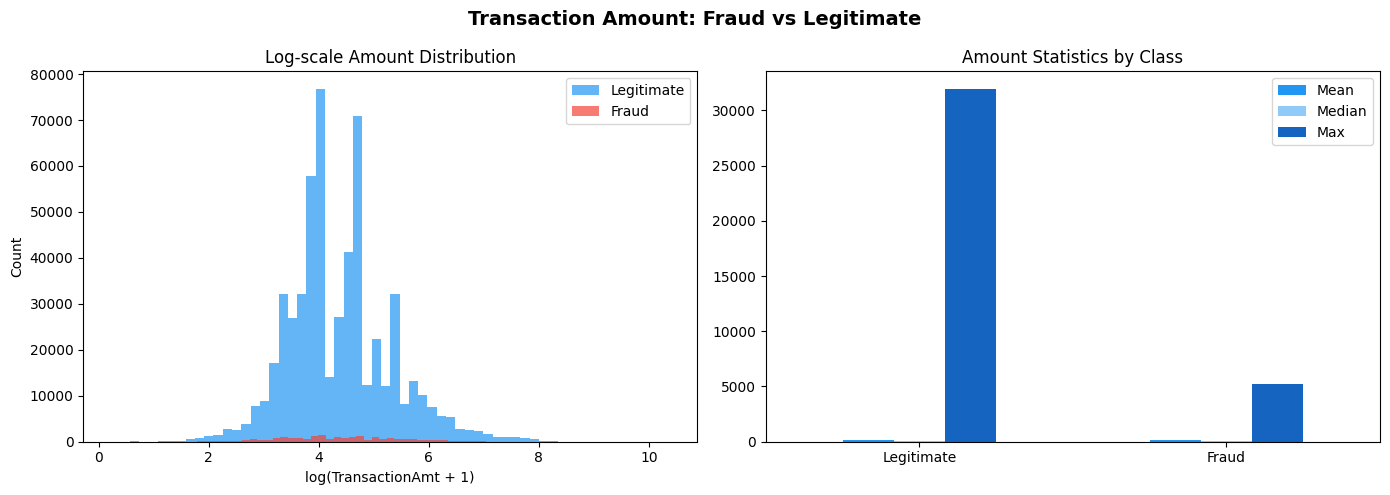

In [7]:
# 1.4.2 Transaction Amount Distribution (Fraud vs Legit)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transaction Amount: Fraud vs Legitimate', fontsize=14, fontweight='bold')

legit_amt = train_transaction.loc[train_transaction['isFraud'] == 0, 'TransactionAmt']
fraud_amt_series = train_transaction.loc[train_transaction['isFraud'] == 1, 'TransactionAmt']

axes[0].hist(np.log1p(legit_amt), bins=60, color='#2196F3', alpha=0.7, label='Legitimate')
axes[0].hist(np.log1p(fraud_amt_series), bins=60, color='#F44336', alpha=0.7, label='Fraud')
axes[0].set_xlabel('log(TransactionAmt + 1)')
axes[0].set_ylabel('Count')
axes[0].set_title('Log-scale Amount Distribution')
axes[0].legend()

stats = train_transaction.groupby('isFraud')['TransactionAmt'].describe()
stats.index = ['Legitimate', 'Fraud']
stats[['mean', '50%', 'max']].plot(kind='bar', ax=axes[1], color=['#2196F3', '#90CAF9', '#1565C0'])
axes[1].set_title('Amount Statistics by Class')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Mean', 'Median', 'Max'])

plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

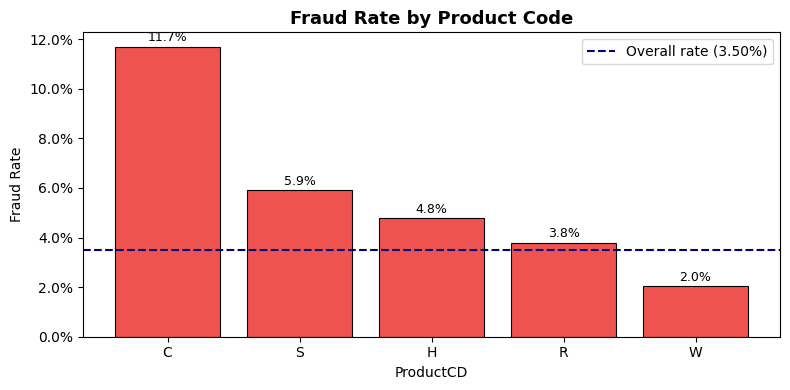

            total  fraud  fraud_rate
ProductCD                           
C           68519   8008      0.1169
S           11628    686      0.0590
H           33024   1574      0.0477
R           37699   1426      0.0378
W          439670   8969      0.0204


In [8]:
# 1.4.3 Fraud Rate by Product Code
fraud_by_product = train_transaction.groupby('ProductCD').agg(
    total=('isFraud', 'count'),
    fraud=('isFraud', 'sum')
).assign(fraud_rate=lambda x: x['fraud'] / x['total']).sort_values('fraud_rate', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(fraud_by_product.index, fraud_by_product['fraud_rate'],
              color='#EF5350', edgecolor='black', linewidth=0.8)
ax.axhline(y=fraud_rate, color='navy', linestyle='--', linewidth=1.5, label=f'Overall rate ({fraud_rate:.2%})')
ax.set_title('Fraud Rate by Product Code', fontsize=13, fontweight='bold')
ax.set_xlabel('ProductCD')
ax.set_ylabel('Fraud Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for bar, rate in zip(bars, fraud_by_product['fraud_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{rate:.1%}', ha='center', va='bottom', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('fraud_by_product.png', dpi=150, bbox_inches='tight')
plt.show()

print(fraud_by_product)

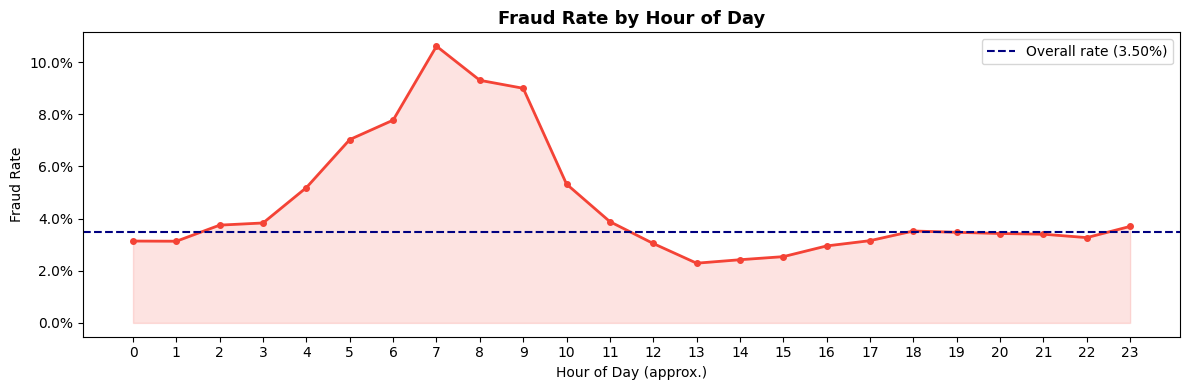

In [9]:
# 1.4.4 Fraud Rate by Hour of Day (time pattern)
# TransactionDT is seconds from a reference point; approximate hour of day
train_transaction['hour'] = (train_transaction['TransactionDT'] // 3600) % 24

fraud_by_hour = train_transaction.groupby('hour').agg(
    total=('isFraud', 'count'),
    fraud=('isFraud', 'sum')
).assign(fraud_rate=lambda x: x['fraud'] / x['total'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(fraud_by_hour.index, fraud_by_hour['fraud_rate'],
        color='#F44336', linewidth=2, marker='o', markersize=4)
ax.axhline(y=fraud_rate, color='navy', linestyle='--', linewidth=1.5, label=f'Overall rate ({fraud_rate:.2%})')
ax.fill_between(fraud_by_hour.index, fraud_by_hour['fraud_rate'], alpha=0.15, color='#F44336')
ax.set_title('Fraud Rate by Hour of Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day (approx.)')
ax.set_ylabel('Fraud Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig('fraud_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# 1.4.5 Missing Value Analysis
def missing_summary(df, name):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
    summary = summary[summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)
    print(f'\n{name}: {len(summary)} columns with missing values out of {df.shape[1]} total')
    print(f'Top 15 most incomplete columns:')
    print(summary.head(15).to_string())
    return summary

missing_trans = missing_summary(train_transaction, 'Transaction Table')
missing_id    = missing_summary(train_identity,    'Identity Table')


Transaction Table: 374 columns with missing values out of 395 total
Top 15 most incomplete columns:
       missing_count  missing_pct
dist2         552913      93.6284
D7            551623      93.4099
D13           528588      89.5093
D14           528353      89.4695
D12           525823      89.0410
D6            517353      87.6068
D8            515614      87.3123
D9            515614      87.3123
V156          508595      86.1237
V139          508595      86.1237
V138          508595      86.1237
V141          508595      86.1237
V146          508595      86.1237
V147          508595      86.1237
V142          508595      86.1237

Identity Table: 38 columns with missing values out of 41 total
Top 15 most incomplete columns:
       missing_count  missing_pct
id_24         139486      96.7088
id_25         139101      96.4419
id_07         139078      96.4259
id_08         139078      96.4259
id_21         139074      96.4231
id_26         139070      96.4204
id_22         139064 

Columns with >50% missing: 174
These will be dropped in preprocessing.


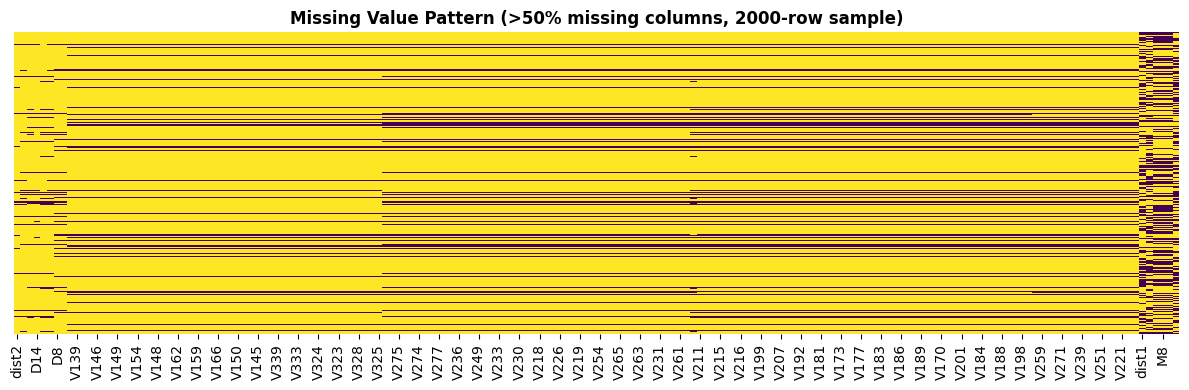

In [11]:
# Visualize missing value heatmap for high-missing columns
high_missing_cols = missing_trans[missing_trans['missing_pct'] > 50].index.tolist()
print(f'Columns with >50% missing: {len(high_missing_cols)}')
print('These will be dropped in preprocessing.')

# Sample-based heatmap (using 2000 rows for speed)
if len(high_missing_cols) > 0:
    sample = train_transaction[high_missing_cols].sample(2000, random_state=SEED)
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(sample.isnull(), cbar=False, yticklabels=False, ax=ax, cmap='viridis')
    ax.set_title('Missing Value Pattern (>50% missing columns, 2000-row sample)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('missing_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 1.5 Join Transaction + Identity Tables

In [12]:
print('Joining tables on TransactionID (left join)...')
df = train_transaction.merge(train_identity, on='TransactionID', how='left')

print(f'Joined shape: {df.shape}')
print(f'Rows with identity info: {train_identity["TransactionID"].nunique():,} '
      f'({train_identity["TransactionID"].nunique()/len(train_transaction):.1%} of transactions)')

# Free memory
del train_transaction, train_identity
gc.collect()
print('Memory freed.')

Joining tables on TransactionID (left join)...
Joined shape: (590540, 435)
Rows with identity info: 144,233 (24.4% of transactions)
Memory freed.


---
## 1.6 Feature Engineering

In [13]:
print('Engineering features...')

# Temporal features
df['hour']        = (df['TransactionDT'] // 3600) % 24
df['day_of_week'] = (df['TransactionDT'] // (3600 * 24)) % 7
df['is_night']    = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(int)
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

# Amount features
df['log_amount']         = np.log1p(df['TransactionAmt'])
df['amount_cents']       = (df['TransactionAmt'] * 100 % 100).round(0)  # cents component
df['is_round_amount']    = (df['amount_cents'] == 0).astype(int)

# Card frequency features (how often does this card appear?)
df['card1_freq'] = df['card1'].map(df['card1'].value_counts())
df['card2_freq'] = df['card2'].map(df['card2'].value_counts())

# Email domain features
df['P_email_domain'] = df['P_emaildomain'].fillna('unknown')
df['R_email_domain'] = df['R_emaildomain'].fillna('unknown')
df['same_email']     = (df['P_email_domain'] == df['R_email_domain']).astype(int)

# has_identity flag
df['has_identity'] = df['id_01'].notna().astype(int)

print('New features added:')
new_features = ['hour', 'day_of_week', 'is_night', 'is_weekend',
                'log_amount', 'amount_cents', 'is_round_amount',
                'card1_freq', 'card2_freq', 'same_email', 'has_identity']
for f in new_features:
    print(f'  + {f}')

Engineering features...
New features added:
  + hour
  + day_of_week
  + is_night
  + is_weekend
  + log_amount
  + amount_cents
  + is_round_amount
  + card1_freq
  + card2_freq
  + same_email
  + has_identity


---
## 1.7 Preprocessing Pipeline

In [14]:
# Separate target
TARGET = 'isFraud'
DROP_COLS = ['TransactionID', 'TransactionDT', 'isFraud',
             'P_emaildomain', 'R_emaildomain']  # replaced by engineered versions

y = df[TARGET].values
X = df.drop(columns=DROP_COLS, errors='ignore')

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape:         {y.shape}')
print(f'Fraud rate:           {y.mean():.4%}')

Feature matrix shape: (590540, 442)
Target shape:         (590540,)
Fraud rate:           3.4990%


In [15]:
# Drop columns with >50% missing (not informative enough)
missing_pct = X.isnull().mean()
high_missing = missing_pct[missing_pct > 0.5].index.tolist()
print(f'Dropping {len(high_missing)} columns with >50% missing values')
X = X.drop(columns=high_missing)
print(f'Feature matrix after drop: {X.shape}')

Dropping 213 columns with >50% missing values
Feature matrix after drop: (590540, 229)


In [16]:
# Identify numeric vs categorical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f'Numeric features:     {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')
print(f'Categorical columns: {cat_cols}')

Numeric features:     219
Categorical features: 10
Categorical columns: ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M6', 'P_email_domain', 'R_email_domain']


In [17]:
# Build sklearn Pipeline
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline,    num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

print('Pipeline defined:')
print(preprocessor)

Pipeline defined:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['TransactionAmt', 'card1', 'card2', 'card3',
                                  'card5', 'addr1', 'addr2', 'C1', 'C2', 'C3',
                                  'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10',
                                  'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3',
                                  'D4', 'D10', 'D11', 'D15', 'V1', 'V2', ...]),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                              

In [18]:
# Train/Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f'Train size: {X_train.shape[0]:,}  |  Fraud rate: {y_train.mean():.4%}')
print(f'Test size:  {X_test.shape[0]:,}  |  Fraud rate: {y_test.mean():.4%}')

Train size: 472,432  |  Fraud rate: 3.4989%
Test size:  118,108  |  Fraud rate: 3.4993%


In [19]:
# Fit pipeline on train, transform both splits
print('Fitting preprocessor on training data...')
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f'Processed train shape: {X_train_processed.shape}')
print(f'Processed test shape:  {X_test_processed.shape}')

# Get final feature names
feature_names = num_cols + cat_cols
print(f'Total features after preprocessing: {len(feature_names)}')

Fitting preprocessor on training data...
Processed train shape: (472432, 229)
Processed test shape:  (118108, 229)
Total features after preprocessing: 229


In [20]:
import pickle

artifacts = {
    'X_train': X_train_processed,
    'X_test':  X_test_processed,
    'y_train': y_train,
    'y_test':  y_test,
    'feature_names': feature_names,
    'preprocessor': preprocessor
}

with open('preprocessing_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('Artifacts saved to preprocessing_artifacts.pkl')

print(f'  Train samples: {X_train_processed.shape[0]:,}')
print(f'  Test samples:  {X_test_processed.shape[0]:,}')
print(f'  Features:      {X_train_processed.shape[1]}')

Artifacts saved to preprocessing_artifacts.pkl
  Train samples: 472,432
  Test samples:  118,108
  Features:      229


---
## Module 2: AutoEncoder — Unsupervised Anomaly Detection

**Key idea:** Train the AutoEncoder *only on legitimate transactions*.
It learns to reconstruct normal patterns. Fraudulent transactions
deviate from those patterns → higher reconstruction error → flagged as anomalies.

No fraud labels are used during training — this is fully unsupervised.

---

## 2.1 Load Artifacts from Module 1

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Load artifacts
with open('/kaggle/working/preprocessing_artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

X_train = artifacts['X_train']
X_test  = artifacts['X_test']
y_train = artifacts['y_train']
y_test  = artifacts['y_test']

print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')
print(f'Fraud rate (train): {y_train.mean():.4%}')

Device: cuda
Train shape: (472432, 229)
Test shape:  (118108, 229)
Fraud rate (train): 3.4989%


## 2.2 Prepare Training Data (Legitimate Transactions Only)

In [22]:
# AutoEncoder trains ONLY on legitimate transactions
X_train_legit = X_train[y_train == 0]
X_train_fraud = X_train[y_train == 1]

print(f'Legitimate train samples: {X_train_legit.shape[0]:,}')
print(f'Fraud train samples:      {X_train_fraud.shape[0]:,}  (NOT used in AE training)')
print(f'\nAutoEncoder will learn normal transaction patterns.')
print(f'Fraud transactions will have high reconstruction error at inference.')

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_legit).to(DEVICE)
X_test_tensor  = torch.FloatTensor(X_test).to(DEVICE)

# DataLoader for batched training
BATCH_SIZE = 1024
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)  # input = target (reconstruction)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f'\nBatch size: {BATCH_SIZE}')
print(f'Batches per epoch: {len(train_loader)}')

Legitimate train samples: 455,902
Fraud train samples:      16,530  (NOT used in AE training)

AutoEncoder will learn normal transaction patterns.
Fraud transactions will have high reconstruction error at inference.

Batch size: 1024
Batches per epoch: 446


## 2.3 AutoEncoder Architecture

In [23]:
INPUT_DIM = X_train.shape[1]  # 229 features

class FraudAutoEncoder(nn.Module):
    """
    Deep AutoEncoder for unsupervised fraud anomaly detection.
    
    Architecture:
        Encoder: 229 → 128 → 64 → 32 (bottleneck)
        Decoder: 32  → 64  → 128 → 229
    
    The bottleneck forces the model to learn a compressed representation
    of normal transactions. Fraudulent ones reconstruct poorly.
    """
    def __init__(self, input_dim, bottleneck_dim=32, dropout_rate=0.2):
        super(FraudAutoEncoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, bottleneck_dim),
            nn.ReLU()
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(128, input_dim)
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def get_reconstruction_error(self, x):
        """Per-sample mean squared reconstruction error."""
        with torch.no_grad():
            reconstructed = self.forward(x)
            error = torch.mean((x - reconstructed) ** 2, dim=1)
        return error.cpu().numpy()


model = FraudAutoEncoder(input_dim=INPUT_DIM, bottleneck_dim=32, dropout_rate=0.2).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f'Model architecture:')
print(model)
print(f'\nTotal parameters: {total_params:,}')

Model architecture:
FraudAutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=229, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): L

## 2.4 Training

In [24]:
EPOCHS    = 30
LR        = 1e-3
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

train_losses = []

print(f'Training AutoEncoder for {EPOCHS} epochs on {X_train_legit.shape[0]:,} legitimate transactions...')
print(f'Learning rate: {LR}  |  Batch size: {BATCH_SIZE}  |  Device: {DEVICE}')
print('-' * 55)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_X)
        loss   = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)
    
    if epoch % 5 == 0 or epoch == 1:
        print(f'  Epoch {epoch:>3}/{EPOCHS}  |  Loss: {avg_loss:.6f}')


Training AutoEncoder for 30 epochs on 455,902 legitimate transactions...
Learning rate: 0.001  |  Batch size: 1024  |  Device: cuda
-------------------------------------------------------
  Epoch   1/30  |  Loss: 5.226156
  Epoch   5/30  |  Loss: 0.637673
  Epoch  10/30  |  Loss: 0.571791
  Epoch  15/30  |  Loss: 0.545097
  Epoch  20/30  |  Loss: 0.519303
  Epoch  25/30  |  Loss: 0.504797
  Epoch  30/30  |  Loss: 0.494426


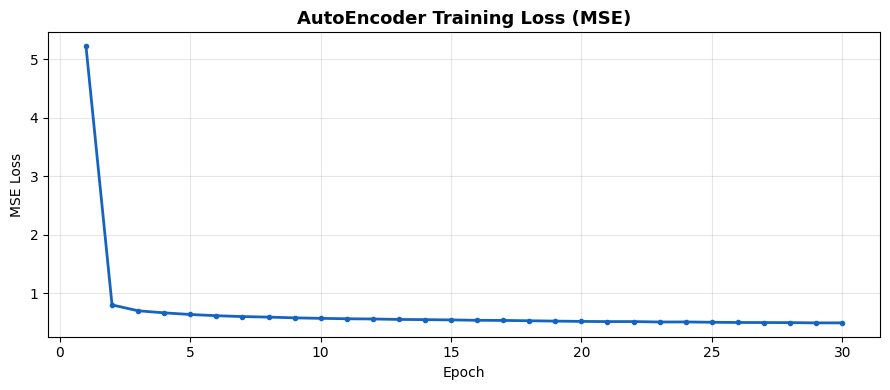

Final training loss: 0.494426


In [25]:
# Plot training loss curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, EPOCHS + 1), train_losses, color='#1565C0', linewidth=2, marker='o', markersize=3)
ax.set_title('AutoEncoder Training Loss (MSE)', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ae_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Final training loss: {train_losses[-1]:.6f}')

## 2.5 Reconstruction Error Analysis

In [26]:
# Compute reconstruction error for all test samples
model.eval()

# Process in batches to avoid OOM
recon_errors = []
EVAL_BATCH = 4096

for i in range(0, len(X_test), EVAL_BATCH):
    batch = torch.FloatTensor(X_test[i:i+EVAL_BATCH]).to(DEVICE)
    errors = model.get_reconstruction_error(batch)
    recon_errors.extend(errors)

recon_errors = np.array(recon_errors)

legit_errors = recon_errors[y_test == 0]
fraud_errors = recon_errors[y_test == 1]

print('Reconstruction Error Statistics:')
print(f'  Legitimate  — mean: {legit_errors.mean():.4f}  |  median: {np.median(legit_errors):.4f}  |  95th pct: {np.percentile(legit_errors, 95):.4f}')
print(f'  Fraud       — mean: {fraud_errors.mean():.4f}  |  median: {np.median(fraud_errors):.4f}  |  95th pct: {np.percentile(fraud_errors, 95):.4f}')
print(f'\nSeparation ratio (fraud mean / legit mean): {fraud_errors.mean() / legit_errors.mean():.2f}x')

Reconstruction Error Statistics:
  Legitimate  — mean: 0.3384  |  median: 0.1478  |  95th pct: 0.8849
  Fraud       — mean: 1.3990  |  median: 0.3225  |  95th pct: 5.4584

Separation ratio (fraud mean / legit mean): 4.13x


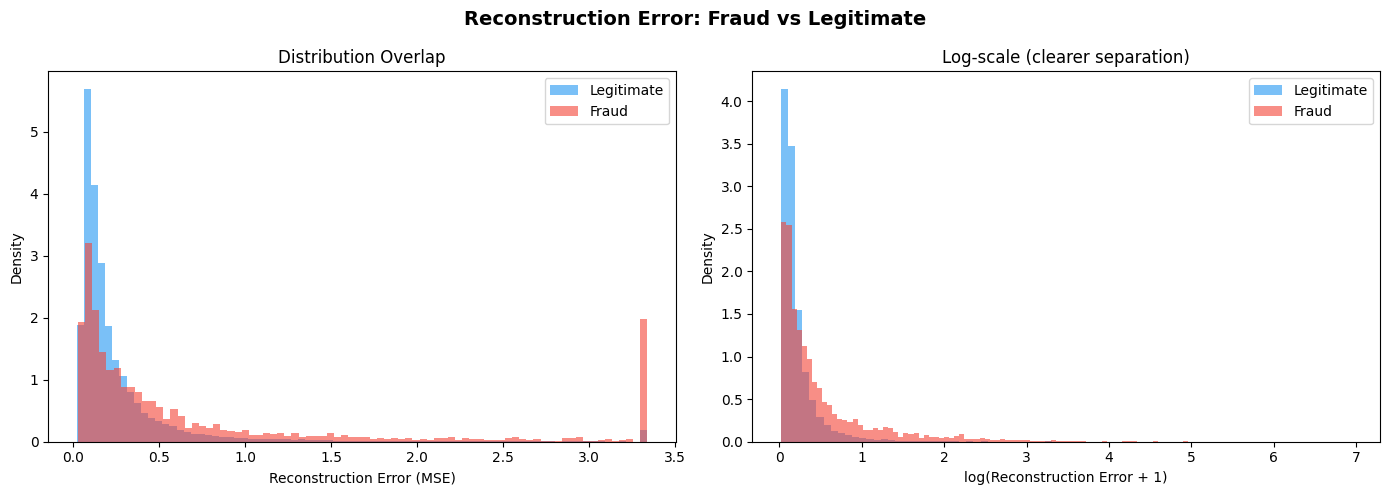

In [27]:
# Visualize reconstruction error distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Reconstruction Error: Fraud vs Legitimate', fontsize=14, fontweight='bold')

# Clip at 99th percentile for visualization clarity
clip_val = np.percentile(recon_errors, 99)
legit_clipped = np.clip(legit_errors, 0, clip_val)
fraud_clipped = np.clip(fraud_errors, 0, clip_val)

axes[0].hist(legit_clipped, bins=80, color='#2196F3', alpha=0.6, label='Legitimate', density=True)
axes[0].hist(fraud_clipped, bins=80, color='#F44336', alpha=0.6, label='Fraud', density=True)
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution Overlap')
axes[0].legend()

# Log scale for better visibility
axes[1].hist(np.log1p(legit_errors), bins=80, color='#2196F3', alpha=0.6, label='Legitimate', density=True)
axes[1].hist(np.log1p(fraud_errors), bins=80, color='#F44336', alpha=0.6, label='Fraud', density=True)
axes[1].set_xlabel('log(Reconstruction Error + 1)')
axes[1].set_ylabel('Density')
axes[1].set_title('Log-scale (clearer separation)')
axes[1].legend()

plt.tight_layout()
plt.savefig('ae_reconstruction_error.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.6 Threshold Optimization

In [28]:
# Use reconstruction error as anomaly score
ae_scores = recon_errors  # higher = more anomalous

# ROC-AUC and PR-AUC
roc_auc = roc_auc_score(y_test, ae_scores)
pr_auc  = average_precision_score(y_test, ae_scores)

print(f'AutoEncoder Performance:')
print(f'  ROC-AUC:  {roc_auc:.4f}')
print(f'  PR-AUC:   {pr_auc:.4f}  (primary metric for imbalanced data)')

# Find F1-optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, ae_scores)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx  = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f'\nOptimal threshold (max F1):')
print(f'  Threshold: {best_threshold:.4f}')
print(f'  F1:        {best_f1:.4f}')
print(f'  Precision: {precisions[best_idx]:.4f}')
print(f'  Recall:    {recalls[best_idx]:.4f}')

AutoEncoder Performance:
  ROC-AUC:  0.6727
  PR-AUC:   0.1153  (primary metric for imbalanced data)

Optimal threshold (max F1):
  Threshold: 1.1220
  F1:        0.1911
  Precision: 0.1745
  Recall:    0.2112


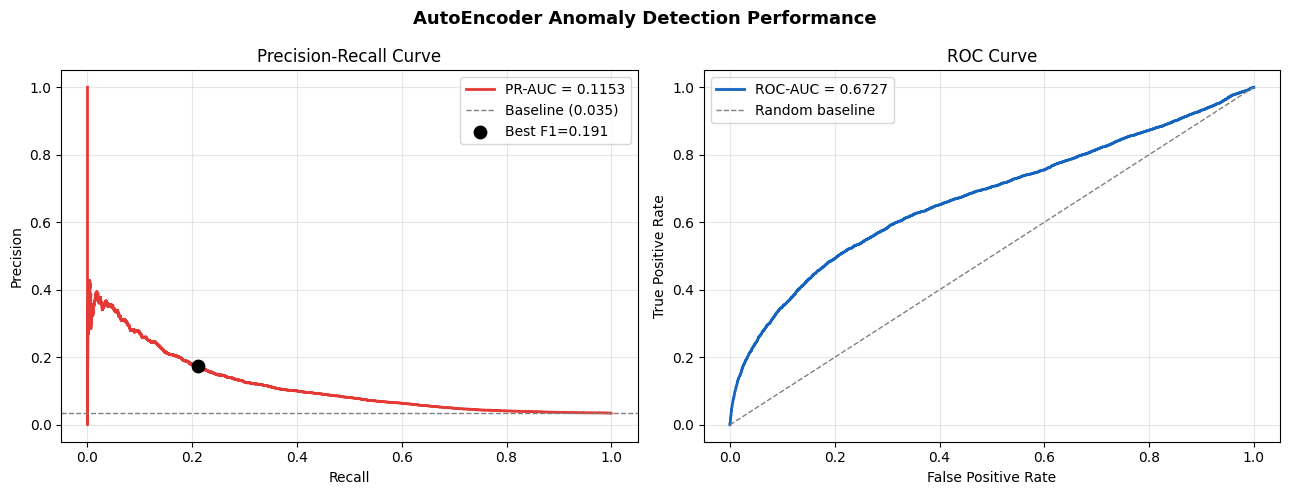

In [29]:
# Plot Precision-Recall and ROC curves
fpr, tpr, roc_thresholds = roc_curve(y_test, ae_scores)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('AutoEncoder Anomaly Detection Performance', fontsize=13, fontweight='bold')

# PR Curve
axes[0].plot(recalls, precisions, color='#E53935', linewidth=2, label=f'PR-AUC = {pr_auc:.4f}')
axes[0].axhline(y=y_test.mean(), color='gray', linestyle='--', linewidth=1, label=f'Baseline ({y_test.mean():.3f})')
axes[0].scatter(recalls[best_idx], precisions[best_idx], color='black', zorder=5, s=80, label=f'Best F1={best_f1:.3f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ROC Curve
axes[1].plot(fpr, tpr, color='#1565C0', linewidth=2, label=f'ROC-AUC = {roc_auc:.4f}')
axes[1].plot([0,1],[0,1], color='gray', linestyle='--', linewidth=1, label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ae_performance_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Classification Report (AutoEncoder @ optimal threshold):
              precision    recall  f1-score   support

  Legitimate       0.97      0.96      0.97    113975
       Fraud       0.17      0.21      0.19      4133

    accuracy                           0.94    118108
   macro avg       0.57      0.59      0.58    118108
weighted avg       0.94      0.94      0.94    118108



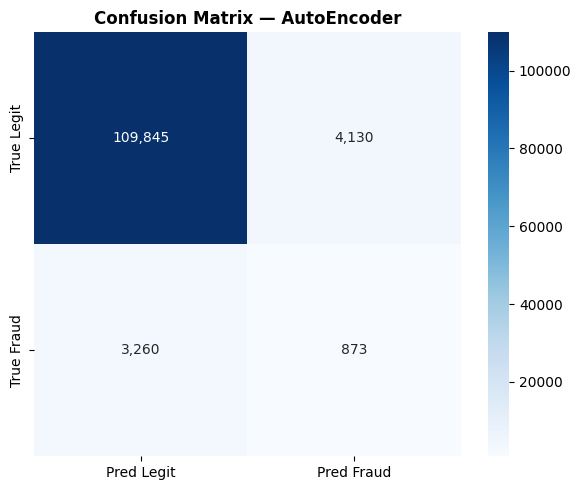


Business Impact @ optimal threshold:
  Fraud caught (TP):         873  (21.1% of all fraud)
  Fraud missed (FN):         3,260
  False alarms (FP):         4,130  (3.6% of legit flagged)


In [30]:
# Classification report at optimal threshold
y_pred_ae = (ae_scores >= best_threshold).astype(int)

print('Classification Report (AutoEncoder @ optimal threshold):')
print(classification_report(y_test, y_pred_ae, target_names=['Legitimate', 'Fraud']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_ae)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['Pred Legit', 'Pred Fraud'],
            yticklabels=['True Legit', 'True Fraud'])
ax.set_title('Confusion Matrix — AutoEncoder', fontweight='bold')
plt.tight_layout()
plt.savefig('ae_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\nBusiness Impact @ optimal threshold:')
print(f'  Fraud caught (TP):         {tp:,}  ({tp/(tp+fn):.1%} of all fraud)')
print(f'  Fraud missed (FN):         {fn:,}')
print(f'  False alarms (FP):         {fp:,}  ({fp/(fp+tn):.1%} of legit flagged)')

In [31]:
# Save AE scores and model for next module
torch.save(model.state_dict(), '/kaggle/working/autoencoder_weights.pt')

ae_results = {
    'ae_scores':       ae_scores,
    'best_threshold':  best_threshold,
    'roc_auc':         roc_auc,
    'pr_auc':          pr_auc,
    'best_f1':         best_f1
}
with open('/kaggle/working/ae_results.pkl', 'wb') as f:
    pickle.dump(ae_results, f)

print('Saved: autoencoder_weights.pt')
print('Saved: ae_results.pkl')

print(f'  AutoEncoder ROC-AUC: {roc_auc:.4f}')
print(f'  AutoEncoder PR-AUC:  {pr_auc:.4f}')
print(f'  Best F1:             {best_f1:.4f}')

Saved: autoencoder_weights.pt
Saved: ae_results.pkl
  AutoEncoder ROC-AUC: 0.6727
  AutoEncoder PR-AUC:  0.1153
  Best F1:             0.1911


---
## Module 3: Supervised Baseline — XGBoost + LightGBM

---


In [32]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report
)
import xgboost as xgb
import lightgbm as lgb

SEED = 42

# Load artifacts
with open('/kaggle/working/preprocessing_artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

with open('/kaggle/working/ae_results.pkl', 'rb') as f:
    ae_results = pickle.load(f)

X_train = artifacts['X_train']
X_test  = artifacts['X_test']
y_train = artifacts['y_train']
y_test  = artifacts['y_test']
feature_names = artifacts['feature_names']

print(f'Train: {X_train.shape} | Fraud rate: {y_train.mean():.4%}')
print(f'Test:  {X_test.shape}  | Fraud rate: {y_test.mean():.4%}')

Train: (472432, 229) | Fraud rate: 3.4989%
Test:  (118108, 229)  | Fraud rate: 3.4993%


In [33]:
# 3.1 XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight (class imbalance ratio): {scale_pos_weight:.1f}')

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='aucpr',
    early_stopping_rounds=20,
    random_state=SEED,
    device='cuda',        # uses your T4 GPU
    verbosity=0
)

print('Training XGBoost...')
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

scale_pos_weight (class imbalance ratio): 27.6
Training XGBoost...
[0]	validation_0-aucpr:0.31305
[50]	validation_0-aucpr:0.50525
[100]	validation_0-aucpr:0.55030
[150]	validation_0-aucpr:0.57355
[200]	validation_0-aucpr:0.59629
[250]	validation_0-aucpr:0.61224
[300]	validation_0-aucpr:0.62931
[350]	validation_0-aucpr:0.64213
[400]	validation_0-aucpr:0.65563
[450]	validation_0-aucpr:0.66702
[499]	validation_0-aucpr:0.67544


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda', early_stopping_rounds=20,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [34]:
# 3.2 LightGBM 
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=SEED,
    verbose=-1
)

print('Training LightGBM...')
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(20, verbose=False),
               lgb.log_evaluation(50)]
)

Training LightGBM...
[50]	valid_0's binary_logloss: 0.411431
[100]	valid_0's binary_logloss: 0.365663
[150]	valid_0's binary_logloss: 0.34619
[200]	valid_0's binary_logloss: 0.331826
[250]	valid_0's binary_logloss: 0.319326
[300]	valid_0's binary_logloss: 0.309078
[350]	valid_0's binary_logloss: 0.299834
[400]	valid_0's binary_logloss: 0.292293
[450]	valid_0's binary_logloss: 0.283723
[500]	valid_0's binary_logloss: 0.277175


LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.05, max_depth=6, n_estimators=500,
               random_state=42, subsample=0.8, verbose=-1)

In [35]:
# 3.3 Evaluate both models
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
lgb_proba  = lgb_model.predict_proba(X_test)[:, 1]
ae_scores  = ae_results['ae_scores']

results = {}
for name, scores in [('AutoEncoder', ae_scores),
                     ('XGBoost',     xgb_proba),
                     ('LightGBM',    lgb_proba)]:
    roc = roc_auc_score(y_test, scores)
    pr  = average_precision_score(y_test, scores)
    results[name] = {'ROC-AUC': roc, 'PR-AUC': pr}

print('\n' + '=' * 50)
print(f'  {"Model":<15} {"ROC-AUC":>10} {"PR-AUC":>10}')
print('=' * 50)
for name, metrics in results.items():
    print(f'  {name:<15} {metrics["ROC-AUC"]:>10.4f} {metrics["PR-AUC"]:>10.4f}')
print('=' * 50)
print(f'  Baseline (random)  {"0.5000":>10} {f"{y_test.mean():.4f}":>10}')


  Model              ROC-AUC     PR-AUC
  AutoEncoder         0.6727     0.1153
  XGBoost             0.9483     0.6755
  LightGBM            0.9393     0.6438
  Baseline (random)      0.5000     0.0350


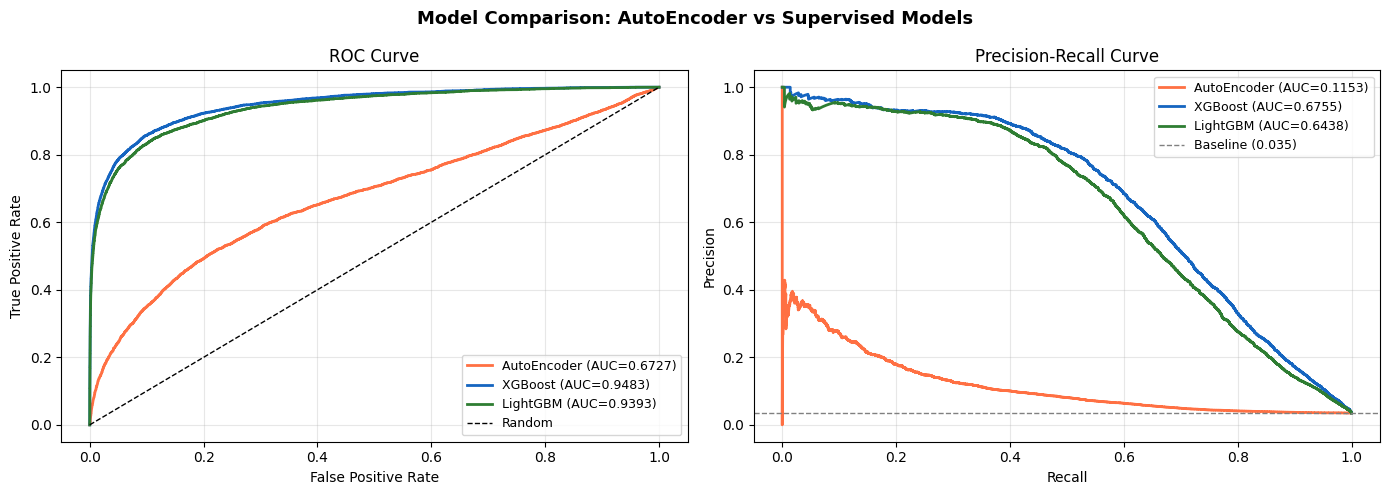

In [36]:
# 3.4 ROC + PR curve comparison (all 3 models)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison: AutoEncoder vs Supervised Models',
             fontsize=13, fontweight='bold')

colors = {'AutoEncoder': '#FF7043', 'XGBoost': '#1565C0', 'LightGBM': '#2E7D32'}

for name, scores in [('AutoEncoder', ae_scores),
                     ('XGBoost',     xgb_proba),
                     ('LightGBM',    lgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    p, r, _     = precision_recall_curve(y_test, scores)
    roc = results[name]['ROC-AUC']
    pr  = results[name]['PR-AUC']
    axes[0].plot(fpr, tpr, color=colors[name], linewidth=2,
                 label=f'{name} (AUC={roc:.4f})')
    axes[1].plot(r, p, color=colors[name], linewidth=2,
                 label=f'{name} (AUC={pr:.4f})')

axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--',
                linewidth=1, label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()

XGBoost Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99    113975
       Fraud       0.71      0.59      0.64      4133

    accuracy                           0.98    118108
   macro avg       0.85      0.79      0.82    118108
weighted avg       0.98      0.98      0.98    118108

Business Impact @ optimal threshold:
  Fraud caught (TP): 2,424  (58.6% of all fraud)
  Fraud missed (FN): 1,709
  False alarms (FP): 990  (0.9% of legit flagged)


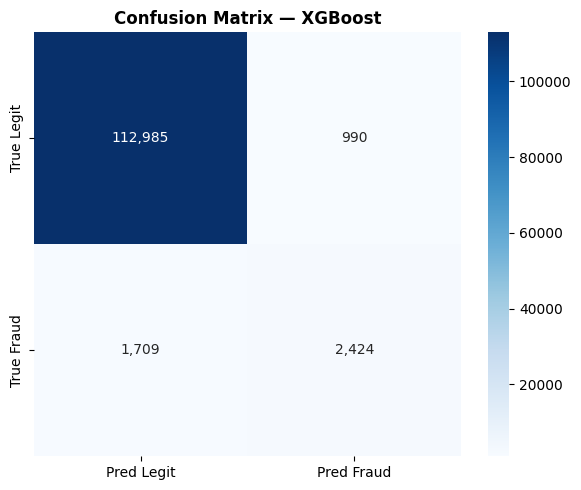

In [37]:
# 3.5 XGBoost at optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_proba)
f1_scores    = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx     = np.argmax(f1_scores)
xgb_threshold = thresholds[best_idx]

y_pred_xgb = (xgb_proba >= xgb_threshold).astype(int)

print('XGBoost Classification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=['Legitimate', 'Fraud']))

cm = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm.ravel()
print(f'Business Impact @ optimal threshold:')
print(f'  Fraud caught (TP): {tp:,}  ({tp/(tp+fn):.1%} of all fraud)')
print(f'  Fraud missed (FN): {fn:,}')
print(f'  False alarms (FP): {fp:,}  ({fp/(fp+tn):.1%} of legit flagged)')

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['Pred Legit', 'Pred Fraud'],
            yticklabels=['True Legit', 'True Fraud'])
ax.set_title('Confusion Matrix — XGBoost', fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

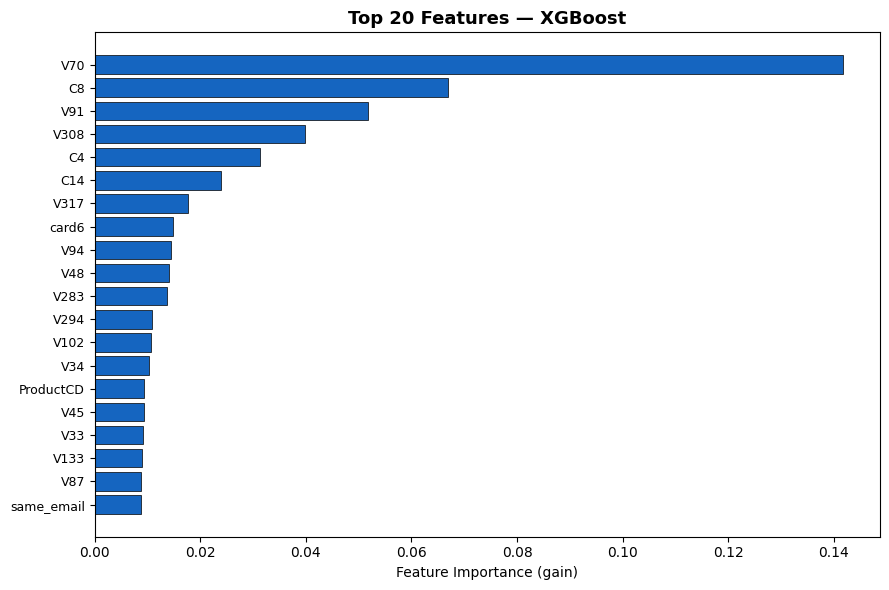

In [38]:
# 3.6 Feature Importance (XGBoost)
importances = xgb_model.feature_importances_
top_n = 20
top_idx   = np.argsort(importances)[-top_n:][::-1]
top_feats = [feature_names[i] for i in top_idx]
top_vals  = importances[top_idx]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(top_n), top_vals[::-1], color='#1565C0', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_feats[::-1], fontsize=9)
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('Top 20 Features — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Save for next module (SHAP)
with open('/kaggle/working/model_artifacts.pkl', 'wb') as f:
    pickle.dump({
        'xgb_model':    xgb_model,
        'lgb_model':    lgb_model,
        'xgb_proba':    xgb_proba,
        'lgb_proba':    lgb_proba,
        'xgb_threshold': xgb_threshold,
        'results':      results
    }, f)

for name, m in results.items():
    print(f'  {name:<15} ROC-AUC={m["ROC-AUC"]:.4f}  PR-AUC={m["PR-AUC"]:.4f}')

  AutoEncoder     ROC-AUC=0.6727  PR-AUC=0.1153
  XGBoost         ROC-AUC=0.9483  PR-AUC=0.6755
  LightGBM        ROC-AUC=0.9393  PR-AUC=0.6438


---
## Module 4: SHAP Explainability
---

In [40]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

SEED = 42

# Load artifacts
with open('/kaggle/working/preprocessing_artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

with open('/kaggle/working/model_artifacts.pkl', 'rb') as f:
    model_artifacts = pickle.load(f)

X_train       = artifacts['X_train']
X_test        = artifacts['X_test']
y_test        = artifacts['y_test']
feature_names = artifacts['feature_names']
xgb_model     = model_artifacts['xgb_model']

print(f'Test set: {X_test.shape}')
print(f'Features: {len(feature_names)}')

Test set: (118108, 229)
Features: 229


In [41]:
# 4.1 Compute SHAP values (sample 5000 for speed)
print('Computing SHAP values...')
explainer = shap.TreeExplainer(xgb_model)

# Sample for SHAP — use stratified sample to include enough fraud cases
np.random.seed(SEED)
fraud_idx  = np.where(y_test == 1)[0]
legit_idx  = np.where(y_test == 0)[0]
sample_fraud = np.random.choice(fraud_idx, size=500,  replace=False)
sample_legit = np.random.choice(legit_idx, size=4500, replace=False)
sample_idx   = np.concatenate([sample_fraud, sample_legit])
np.random.shuffle(sample_idx)

X_sample   = X_test[sample_idx]
y_sample   = y_test[sample_idx]

shap_values = explainer.shap_values(X_sample)
print(f'SHAP values shape: {shap_values.shape}')
print(f'Sample fraud rate: {y_sample.mean():.2%}')

Computing SHAP values...
SHAP values shape: (5000, 229)
Sample fraud rate: 10.00%


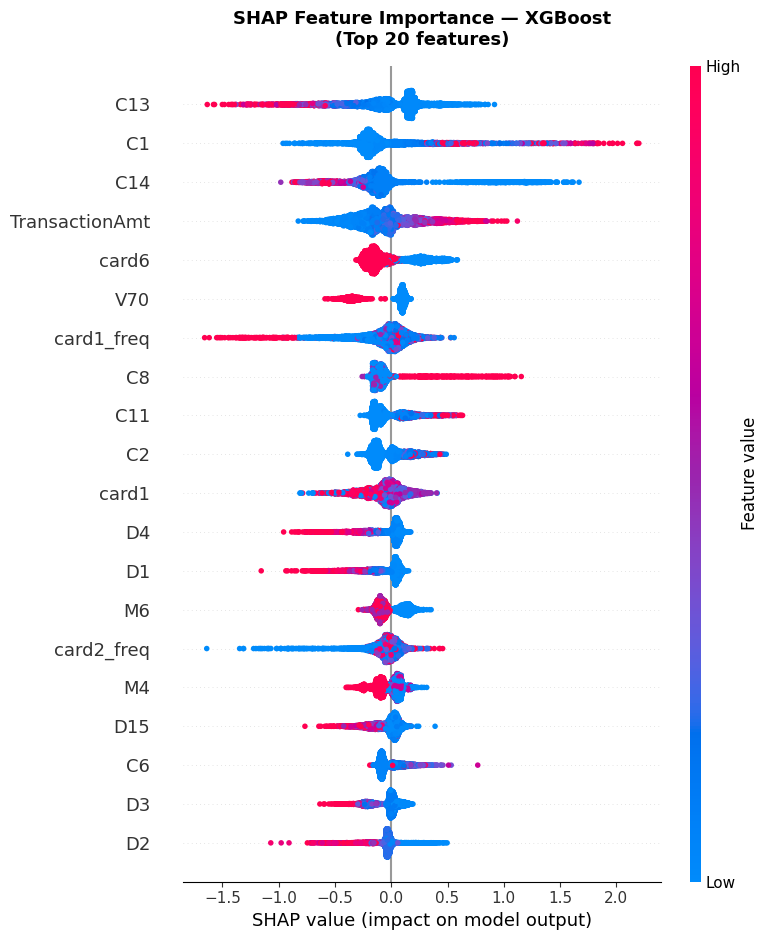

Saved: shap_summary_beeswarm.png


In [42]:
# 4.2 Global Feature Importance — Beeswarm summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_sample,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance — XGBoost\n(Top 20 features)', 
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_summary_beeswarm.png')

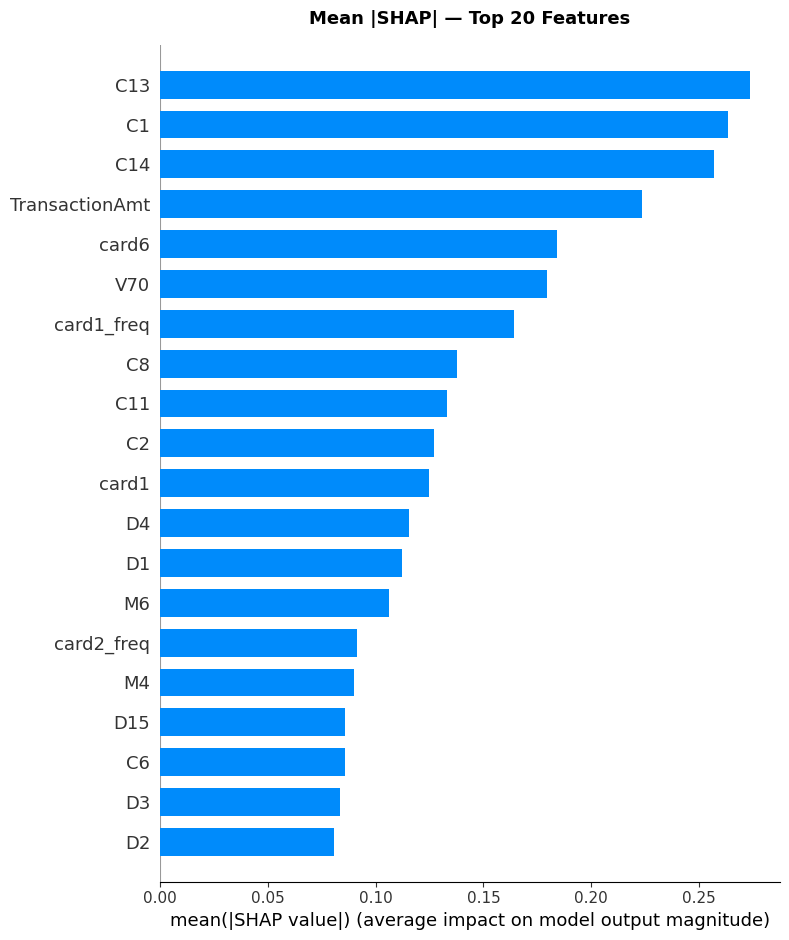

In [43]:
# 4.3 Bar plot — mean absolute SHAP
plt.figure(figsize=(9, 7))
shap.summary_plot(
    shap_values, X_sample,
    feature_names=feature_names,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Mean |SHAP| — Top 20 Features', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Most confident fraud prediction: 0.9996 probability


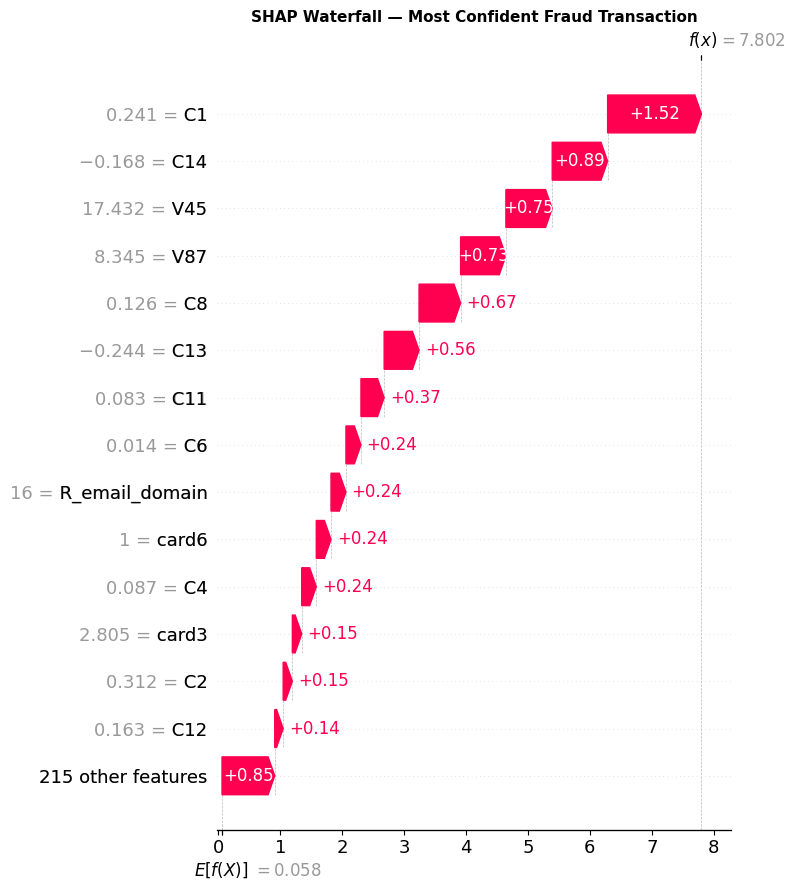

In [44]:
# 4.4 Waterfall plot — single fraud transaction
# Pick the fraud transaction the model is most confident about
from xgboost import XGBClassifier

xgb_proba_sample = xgb_model.predict_proba(X_sample)[:, 1]
fraud_in_sample  = np.where(y_sample == 1)[0]
most_confident_fraud_idx = fraud_in_sample[np.argmax(xgb_proba_sample[fraud_in_sample])]

print(f'Most confident fraud prediction: {xgb_proba_sample[most_confident_fraud_idx]:.4f} probability')

shap_explanation = shap.Explanation(
    values         = shap_values[most_confident_fraud_idx],
    base_values    = explainer.expected_value,
    data           = X_sample[most_confident_fraud_idx],
    feature_names  = feature_names
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_explanation, max_display=15, show=False)
plt.title('SHAP Waterfall — Most Confident Fraud Transaction',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

Most confident legit prediction: 0.0002 probability


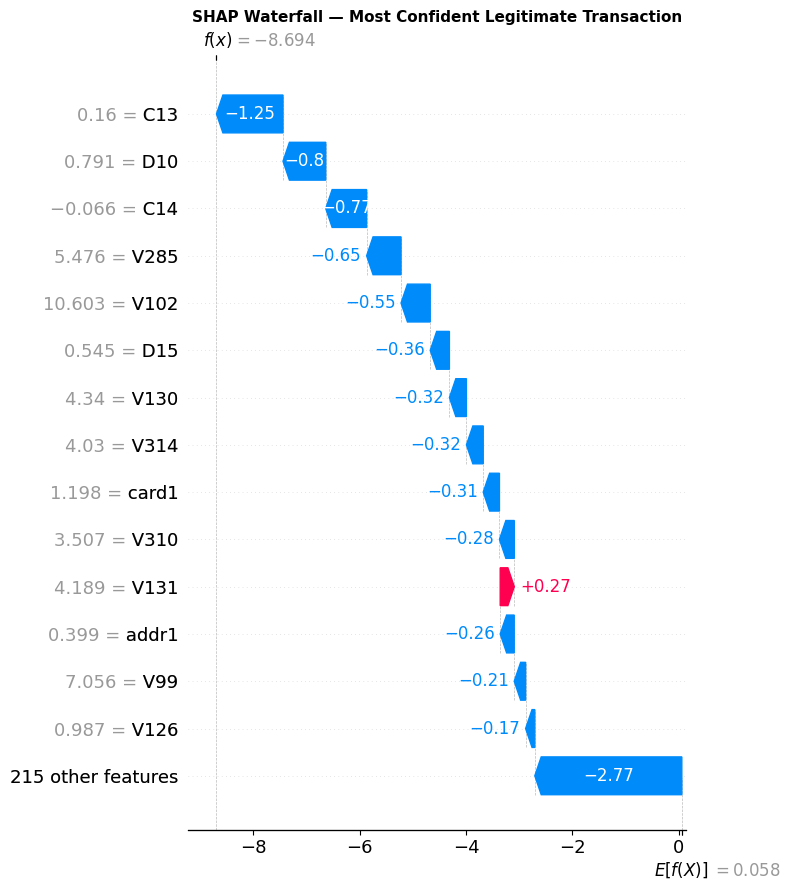

In [45]:
# 4.5 Waterfall plot — single legitimate transaction
legit_in_sample = np.where(y_sample == 0)[0]
most_confident_legit_idx = legit_in_sample[np.argmin(xgb_proba_sample[legit_in_sample])]

print(f'Most confident legit prediction: {xgb_proba_sample[most_confident_legit_idx]:.4f} probability')

shap_explanation_legit = shap.Explanation(
    values         = shap_values[most_confident_legit_idx],
    base_values    = explainer.expected_value,
    data           = X_sample[most_confident_legit_idx],
    feature_names  = feature_names
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_explanation_legit, max_display=15, show=False)
plt.title('SHAP Waterfall — Most Confident Legitimate Transaction',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_legit.png', dpi=150, bbox_inches='tight')
plt.show()

Top feature by mean |SHAP|: C13


<Figure size 800x500 with 0 Axes>

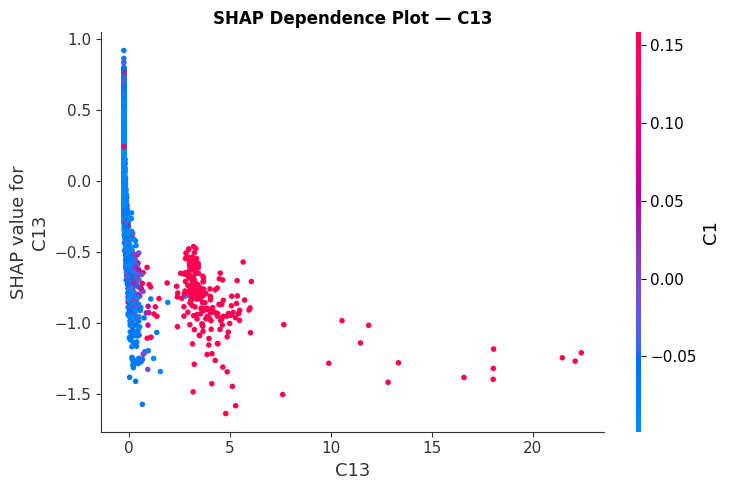

  Top feature: C13
  SHAP plots saved.


In [46]:
# 4.6 Dependence plot — top feature 
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature_idx  = np.argmax(mean_abs_shap)
top_feature_name = feature_names[top_feature_idx]

print(f'Top feature by mean |SHAP|: {top_feature_name}')

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    top_feature_idx, shap_values, X_sample,
    feature_names=feature_names,
    show=False
)
plt.title(f'SHAP Dependence Plot — {top_feature_name}',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence_top.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'  Top feature: {top_feature_name}')
print(f'  SHAP plots saved.')

---
## Module 5: MLflow Experiment Tracking
---

In [47]:
!pip install mlflow -q

In [48]:
import pickle
import numpy as np
import mlflow
import mlflow.xgboost
import mlflow.pytorch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score
)
import torch

# Load artifacts
with open('/kaggle/working/preprocessing_artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

with open('/kaggle/working/model_artifacts.pkl', 'rb') as f:
    model_artifacts = pickle.load(f)

with open('/kaggle/working/ae_results.pkl', 'rb') as f:
    ae_results = pickle.load(f)

X_train       = artifacts['X_train']
X_test        = artifacts['X_test']
y_train       = artifacts['y_train']
y_test        = artifacts['y_test']
feature_names = artifacts['feature_names']
xgb_model     = model_artifacts['xgb_model']
lgb_model     = model_artifacts['lgb_model']
xgb_proba     = model_artifacts['xgb_proba']
lgb_proba     = model_artifacts['lgb_proba']
xgb_threshold = model_artifacts['xgb_threshold']
ae_scores     = ae_results['ae_scores']
ae_threshold  = ae_results['best_threshold']

print('Artifacts loaded.')

Artifacts loaded.


In [49]:
# 5.1 Setup MLflow
mlflow.set_tracking_uri('/kaggle/working/mlruns')
mlflow.set_experiment('fraud-detection-system')
print('MLflow experiment set: fraud-detection-system')

MLflow experiment set: fraud-detection-system


In [50]:
# 5.2 Helper: compute all metrics at a given threshold
def compute_metrics(y_true, scores, threshold):
    y_pred = (scores >= threshold).astype(int)
    return {
        'roc_auc':   roc_auc_score(y_true, scores),
        'pr_auc':    average_precision_score(y_true, scores),
        'f1':        f1_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall':    recall_score(y_true, y_pred),
        'threshold': threshold
    }

In [51]:
# 5.3 Log AutoEncoder run
with mlflow.start_run(run_name='AutoEncoder-Unsupervised'):
    params = {
        'model_type':      'AutoEncoder',
        'approach':        'unsupervised',
        'input_dim':       X_train.shape[1],
        'bottleneck_dim':  32,
        'hidden_layers':   '128-64-32-64-128',
        'dropout_rate':    0.2,
        'epochs':          30,
        'batch_size':      1024,
        'learning_rate':   1e-3,
        'optimizer':       'Adam',
        'weight_decay':    1e-5,
        'train_on':        'legitimate_only',
        'n_train_samples': int((y_train == 0).sum()),
        'n_features':      X_train.shape[1]
    }
    mlflow.log_params(params)

    metrics = compute_metrics(y_test, ae_scores, ae_threshold)
    mlflow.log_metrics(metrics)

    mlflow.log_metric('separation_ratio', 1.3990 / 0.3384)  # fraud/legit mean recon error

    print('AutoEncoder run logged.')
    print(f"  ROC-AUC: {metrics['roc_auc']:.4f}  PR-AUC: {metrics['pr_auc']:.4f}  F1: {metrics['f1']:.4f}")

AutoEncoder run logged.
  ROC-AUC: 0.6727  PR-AUC: 0.1153  F1: 0.1911


In [52]:
# 5.4 Log XGBoost run
with mlflow.start_run(run_name='XGBoost-Supervised'):
    xgb_params = xgb_model.get_params()
    mlflow.log_params({
        'model_type':        'XGBoost',
        'approach':          'supervised',
        'n_estimators':      xgb_params.get('n_estimators'),
        'max_depth':         xgb_params.get('max_depth'),
        'learning_rate':     xgb_params.get('learning_rate'),
        'subsample':         xgb_params.get('subsample'),
        'colsample_bytree':  xgb_params.get('colsample_bytree'),
        'scale_pos_weight':  xgb_params.get('scale_pos_weight'),
        'imbalance_strategy':'scale_pos_weight',
        'n_train_samples':   len(y_train),
        'n_features':        X_train.shape[1]
    })

    metrics = compute_metrics(y_test, xgb_proba, xgb_threshold)
    mlflow.log_metrics(metrics)
    mlflow.xgboost.log_model(xgb_model, artifact_path='xgb_model')

    print('XGBoost run logged.')
    print(f"  ROC-AUC: {metrics['roc_auc']:.4f}  PR-AUC: {metrics['pr_auc']:.4f}  F1: {metrics['f1']:.4f}")

2026/04/09 21:58:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost run logged.
  ROC-AUC: 0.9483  PR-AUC: 0.6755  F1: 0.6424


In [53]:
# 5.5 Log LightGBM run
from sklearn.metrics import precision_recall_curve
import mlflow.lightgbm

precisions, recalls, thresholds = precision_recall_curve(y_test, lgb_proba)
f1_scores   = 2 * precisions * recalls / (precisions + recalls + 1e-8)
lgb_threshold = thresholds[np.argmax(f1_scores)]

with mlflow.start_run(run_name='LightGBM-Supervised'):
    lgb_params = lgb_model.get_params()
    mlflow.log_params({
        'model_type':        'LightGBM',
        'approach':          'supervised',
        'n_estimators':      lgb_params.get('n_estimators'),
        'max_depth':         lgb_params.get('max_depth'),
        'learning_rate':     lgb_params.get('learning_rate'),
        'subsample':         lgb_params.get('subsample'),
        'colsample_bytree':  lgb_params.get('colsample_bytree'),
        'class_weight':      'balanced',
        'imbalance_strategy':'class_weight_balanced',
        'n_train_samples':   len(y_train),
        'n_features':        X_train.shape[1]
    })

    metrics = compute_metrics(y_test, lgb_proba, lgb_threshold)
    mlflow.log_metrics(metrics)
    mlflow.lightgbm.log_model(lgb_model, artifact_path='lgb_model')

    print('LightGBM run logged.')
    print(f"  ROC-AUC: {metrics['roc_auc']:.4f}  PR-AUC: {metrics['pr_auc']:.4f}  F1: {metrics['f1']:.4f}")

2026/04/09 21:58:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/09 21:58:34 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM run logged.
  ROC-AUC: 0.9393  PR-AUC: 0.6438  F1: 0.6201


In [64]:
# 5.6 Summary table
runs = mlflow.search_runs(experiment_names=['fraud-detection-system'])
runs = runs.sort_values('start_time', ascending=False)
runs = runs.drop_duplicates(subset='tags.mlflow.runName', keep='first')

summary_cols = ['tags.mlflow.runName',
                'metrics.roc_auc', 'metrics.pr_auc',
                'metrics.f1', 'metrics.precision', 'metrics.recall']
summary = runs[summary_cols].rename(columns={
    'tags.mlflow.runName': 'Model',
    'metrics.roc_auc':     'ROC-AUC',
    'metrics.pr_auc':      'PR-AUC',
    'metrics.f1':          'F1',
    'metrics.precision':   'Precision',
    'metrics.recall':      'Recall'
}).sort_values('ROC-AUC', ascending=False)

print(summary.to_string(index=False))
print('\nMLflow runs saved to /kaggle/working/mlruns')

                   Model  ROC-AUC  PR-AUC     F1  Precision  Recall
      XGBoost-Supervised   0.9483  0.6755 0.6424     0.7100  0.5865
     LightGBM-Supervised   0.9393  0.6438 0.6201     0.6723  0.5754
AutoEncoder-Unsupervised   0.6727  0.1153 0.1911     0.1745  0.2112

MLflow runs saved to /kaggle/working/mlruns
